In [ ]:
# Problem 3 - Neural Network Architecture Visualization
# Credit Card Fraud Detection

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

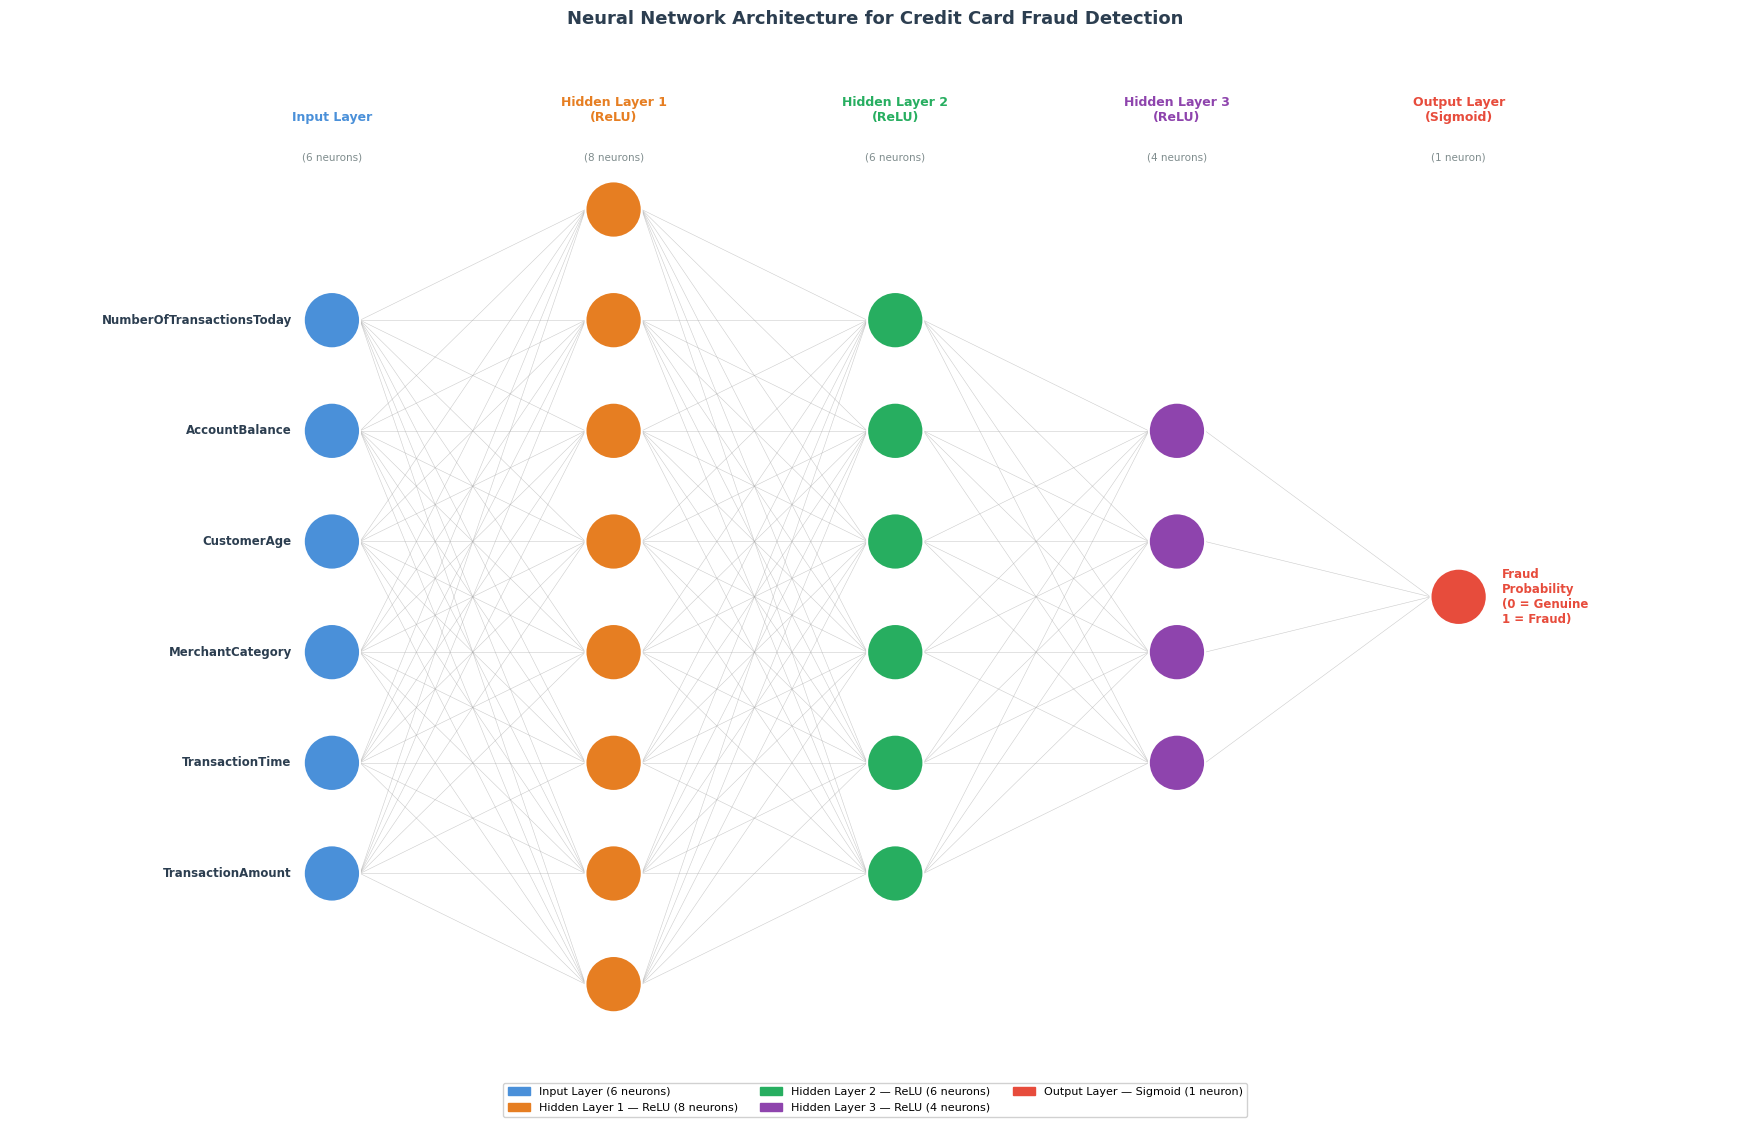

In [ ]:
# neurons per layer: input -> hidden x3 -> output
layer_sizes = [6, 8, 6, 4, 1]

layer_labels = [
    "Input Layer",
    "Hidden Layer 1\n(ReLU)",
    "Hidden Layer 2\n(ReLU)",
    "Hidden Layer 3\n(ReLU)",
    "Output Layer\n(Sigmoid)",
]

input_feature_labels = [
    "TransactionAmount",
    "TransactionTime",
    "MerchantCategory",
    "CustomerAge",
    "AccountBalance",
    "NumberOfTransactionsToday",
]

n_layers       = len(layer_sizes)
h_spacing      = 2.8          # horizontal gap between layers
v_spacing      = 1.1          # vertical gap between neurons in a layer
neuron_radius  = 0.28
max_neurons    = max(layer_sizes)

def get_neuron_positions(layer_sizes, h_spacing, v_spacing):
    positions = {}
    for l_idx, n_neurons in enumerate(layer_sizes):
        x = l_idx * h_spacing
        # center each layer vertically relative to the tallest one
        total_height = (max_neurons - 1) * v_spacing
        layer_height = (n_neurons - 1) * v_spacing
        y_start = (total_height - layer_height) / 2
        positions[l_idx] = [(x, y_start + n * v_spacing) for n in range(n_neurons)]
    return positions

positions = get_neuron_positions(layer_sizes, h_spacing, v_spacing)

fig_width  = h_spacing * (n_layers - 1) + 6.5   # extra room for input labels
fig_height = (max_neurons - 1) * v_spacing + 3.0

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.set_aspect("equal")
ax.axis("off")

layer_colors = {
    0: "#4A90D9",   # input  - blue
    1: "#E67E22",   # hidden 1 - orange
    2: "#27AE60",   # hidden 2 - green
    3: "#8E44AD",   # hidden 3 - purple
    4: "#E74C3C",   # output - red
}

# draw connections before neurons so neurons render on top
for l_idx in range(n_layers - 1):
    for (x1, y1) in positions[l_idx]:
        for (x2, y2) in positions[l_idx + 1]:
            line = Line2D(
                [x1 + neuron_radius, x2 - neuron_radius],
                [y1, y2],
                linewidth=0.4,
                color="#AAAAAA",
                alpha=0.6,
                zorder=1,
            )
            ax.add_line(line)

for l_idx, neuron_list in positions.items():
    color = layer_colors[l_idx]
    for n_idx, (x, y) in enumerate(neuron_list):
        circle = plt.Circle(
            (x, y),
            neuron_radius,
            color=color,
            ec="white",
            linewidth=1.5,
            zorder=2,
        )
        ax.add_patch(circle)

# label each input neuron with its feature name
for n_idx, (x, y) in enumerate(positions[0]):
    label = input_feature_labels[n_idx]
    ax.text(
        x - neuron_radius - 0.12, y,
        label,
        ha="right",
        va="center",
        fontsize=8.5,
        color="#2C3E50",
        fontweight="bold",
    )

top_y = (max_neurons - 1) * v_spacing + 0.85

for l_idx in range(n_layers):
    x = l_idx * h_spacing
    color = layer_colors[l_idx]
    ax.text(
        x, top_y,
        layer_labels[l_idx],
        ha="center",
        va="bottom",
        fontsize=9,
        color=color,
        fontweight="bold",
        multialignment="center",
    )
    ax.text(
        x, top_y - 0.38,
        f"({layer_sizes[l_idx]} neuron{'s' if layer_sizes[l_idx] > 1 else ''})",
        ha="center",
        va="bottom",
        fontsize=7.5,
        color="#7F8C8D",
    )

out_x, out_y = positions[n_layers - 1][0]
ax.text(
    out_x + neuron_radius + 0.15, out_y,
    "Fraud\nProbability\n(0 = Genuine\n1 = Fraud)",
    ha="left",
    va="center",
    fontsize=8.5,
    color="#E74C3C",
    fontweight="bold",
)

fig.suptitle(
    "Neural Network Architecture for Credit Card Fraud Detection",
    fontsize=13,
    fontweight="bold",
    color="#2C3E50",
    y=1.01,
)

legend_patches = [
    mpatches.Patch(color=layer_colors[0], label="Input Layer (6 neurons)"),
    mpatches.Patch(color=layer_colors[1], label="Hidden Layer 1 — ReLU (8 neurons)"),
    mpatches.Patch(color=layer_colors[2], label="Hidden Layer 2 — ReLU (6 neurons)"),
    mpatches.Patch(color=layer_colors[3], label="Hidden Layer 3 — ReLU (4 neurons)"),
    mpatches.Patch(color=layer_colors[4], label="Output Layer — Sigmoid (1 neuron)"),
]
ax.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    fontsize=8,
    framealpha=0.9,
)

x_min = -3.2
x_max = (n_layers - 1) * h_spacing + 2.8
y_min = -0.6
y_max = (max_neurons - 1) * v_spacing + 1.4

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()
